# Sensor Data Cleaning

Takes the raw sensor CSV and produces a clean dataset ready for modeling.

**Decisions made in this notebook** (based on what EDA showed):
1. Drop duplicate timestamps
2. Snap timestamps to the 5-min grid (removes `:02` second drift — 171 affected rows in Feb data)
3. Reindex onto the full 5-min grid so missing slots become NaN rows
4. Interpolate short gaps (≤ 1 hour), leave long gaps as NaN segment breaks
5. Tag each row with a `segment_id` so downstream code never builds windows across gaps

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 1. Load raw data

In [4]:
df = pd.read_csv("sensors_data.csv", parse_dates=["recorded_at"])
df = df.sort_values("recorded_at").reset_index(drop=True)
print(f"Raw rows: {len(df):,}")
print(f"Date range: {df['recorded_at'].min()}  ->  {df['recorded_at'].max()}")

Raw rows: 10,498
Date range: 2026-02-12 17:30:00  ->  2026-05-31 09:20:00


## 2. Handle duplicates

EDA flagged some duplicate timestamps. We keep the first occurrence.

In [5]:
n_before = len(df)
df = df.drop_duplicates(subset="recorded_at", keep="first").reset_index(drop=True)
print(f"Removed {n_before - len(df)} duplicate rows")

Removed 1 duplicate rows


## 3. Snap timestamps to 5-minute grid

171 rows (mostly from Feb 2026 after a device reboot) have a `:02` second drift. Round to nearest 5 min so they land cleanly on the grid.

In [6]:
df["recorded_at"] = df["recorded_at"].dt.round("5min")

# Rounding can create new duplicates - resolve by averaging
sensors = ["light", "humidity", "temperature", "pressure"]
df = df.groupby("recorded_at", as_index=False)[sensors].mean()
print(f"Rows after snapping & dedup: {len(df):,}")
df.head()

Rows after snapping & dedup: 10,497


,recorded_at,light,humidity,temperature,pressure
0,2026-02-12 17:30:00,440.0,100.0,19.7,1014.6
1,2026-02-12 17:35:00,546.0,100.0,19.6,1014.6
2,2026-02-12 17:40:00,549.0,100.0,19.6,1014.5
3,2026-02-12 17:45:00,528.0,100.0,19.6,1014.4
4,2026-02-12 17:50:00,568.0,100.0,19.5,1014.3


## 4. Reindex onto the full 5-min grid

Inserts NaN rows for every missing slot, making gaps explicit.

In [7]:
full_range = pd.date_range(
    start=df["recorded_at"].min(),
    end=df["recorded_at"].max(),
    freq="5min"
)
df = df.set_index("recorded_at").reindex(full_range)
df.index.name = "recorded_at"
print(f"Total grid points: {len(df):,}")
print(f"Missing rows: {df['temperature'].isna().sum():,}  ({df['temperature'].isna().mean() * 100:.2f}%)")

Total grid points: 31,007
Missing rows: 20,510  (66.15%)


## 5. Identify gap segments

Any run of consecutive NaN rows is a gap. We classify each gap by length:
- **Short (≤ 12 readings = 1 hour)**: safe to interpolate
- **Long (> 12 readings)**: leave as NaN, mark as segment boundary

In [8]:
GAP_THRESHOLD = 12  # readings = 1 hour at 5-min cadence

# Find runs of NaN
is_missing = df["temperature"].isna()
# group_id increments every time we switch between missing and present
group_id = (is_missing != is_missing.shift()).cumsum()
gap_sizes = is_missing.groupby(group_id).transform("sum").where(is_missing, 0)

df["_gap_size"] = gap_sizes
df["_is_long_gap"] = (gap_sizes > GAP_THRESHOLD)

# Summary
gap_runs = is_missing.groupby(group_id).sum()
gap_runs = gap_runs[gap_runs > 0]
print(f"Total gap runs: {len(gap_runs)}")
print(f"Short gaps (will interpolate): {(gap_runs <= GAP_THRESHOLD).sum()}")
print(f"Long gaps (will leave as NaN): {(gap_runs > GAP_THRESHOLD).sum()}")
print()
print("Long gaps:")
long_gaps_summary = gap_runs[gap_runs > GAP_THRESHOLD].sort_values(ascending=False)
print(long_gaps_summary.to_string())

Total gap runs: 142
Short gaps (will interpolate): 139
Long gaps (will leave as NaN): 3

Long gaps:
temperature
40     19083
226      306
6        231


## 6. Interpolate short gaps

Linear interpolation, but **only** for short gaps. The `limit` argument caps how far interpolation can stretch.

In [9]:
for col in sensors:
    df[col] = df[col].interpolate(
        method="linear",
        limit=GAP_THRESHOLD,
        limit_area="inside"
    )

print(f"Remaining NaN rows after interpolation: {df['temperature'].isna().sum():,}")
print("These should all be from the long gaps we chose not to bridge.")

Remaining NaN rows after interpolation: 19,584
These should all be from the long gaps we chose not to bridge.


## 7. Assign segment IDs

Each contiguous block of non-NaN data gets its own `segment_id`. The LSTM training code will use this to avoid building windows that cross gaps.

In [10]:
# A new segment starts every time data resumes after a long gap
df["segment_id"] = (~df["_is_long_gap"]).astype(int).diff().eq(1).cumsum()
# Rows inside long gaps get segment_id = -1 (will be dropped before training)
df.loc[df["_is_long_gap"], "segment_id"] = -1

# Cleanup helper columns
df = df.drop(columns=["_gap_size", "_is_long_gap"])

# Segment summary
segments = df[df["segment_id"] >= 0].groupby("segment_id").agg(
    start=("segment_id", lambda x: x.index.min()),
    end=("segment_id", lambda x: x.index.max()),
    n_readings=("segment_id", "size"),
)
segments["duration"] = segments["end"] - segments["start"]
print(f"Number of clean segments: {len(segments)}")
print()
print(segments.to_string())

Number of clean segments: 4

                         start                 end  n_readings         duration
segment_id                                                                     
0          2026-02-12 17:30:00 2026-02-18 20:30:00        1765  6 days 03:00:00
1          2026-02-19 15:50:00 2026-02-28 14:50:00        2581  8 days 23:00:00
2          2026-05-05 21:10:00 2026-05-14 11:55:00        2482  8 days 14:45:00
3          2026-05-15 13:30:00 2026-05-31 09:20:00        4559 15 days 19:50:00


## 8. Quick visual sanity check

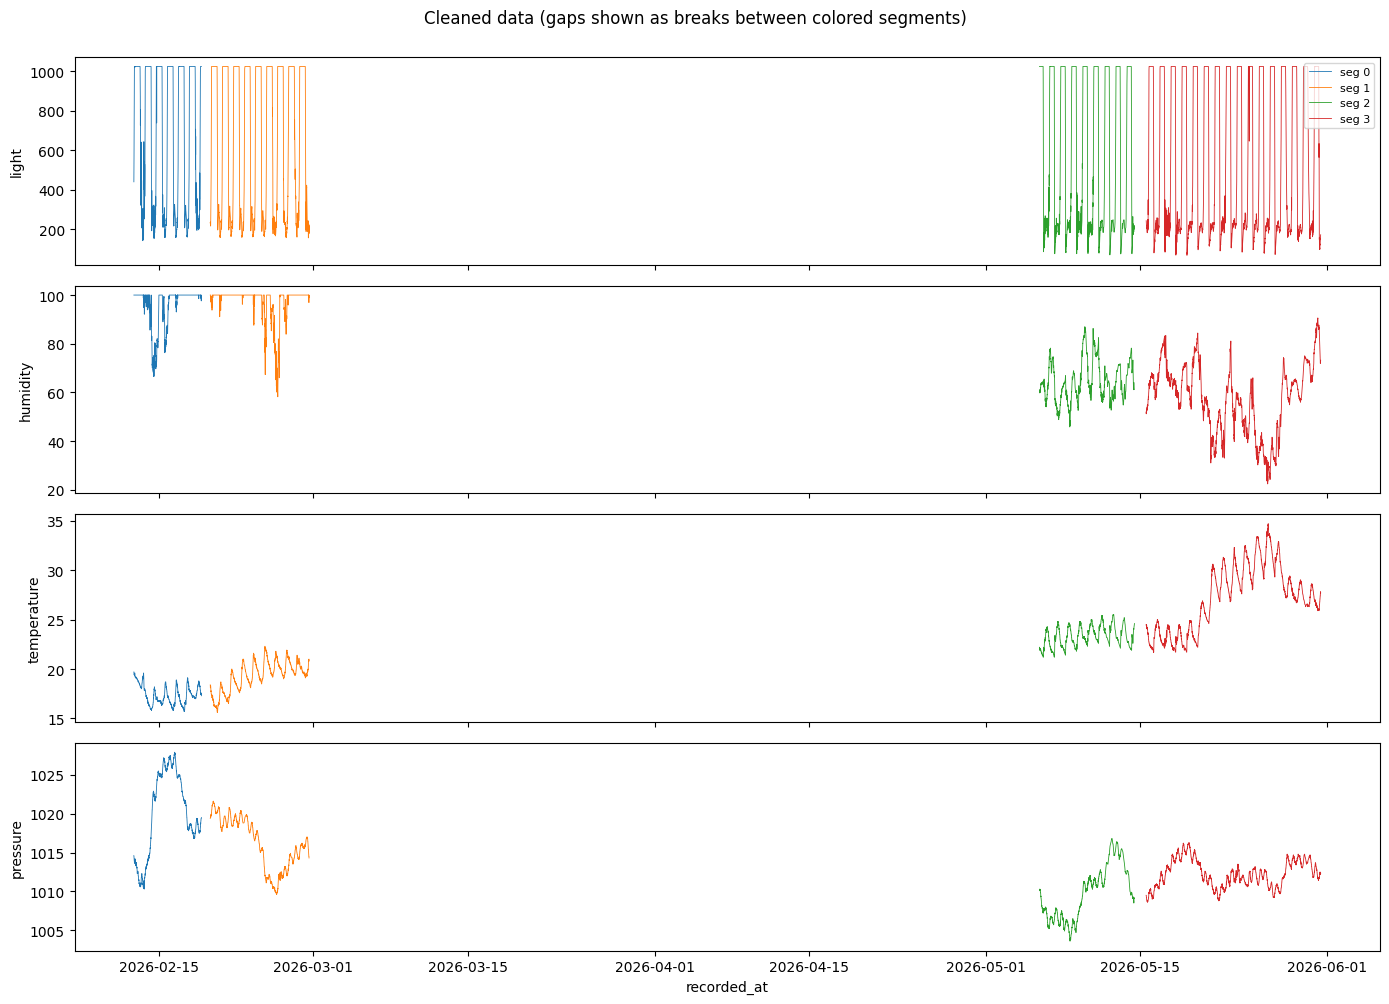

In [11]:
fig, axes = plt.subplots(len(sensors), 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, sensors):
    # Plot each segment in a different color so gaps are visible
    for seg_id, seg in df[df["segment_id"] >= 0].groupby("segment_id"):
        ax.plot(seg.index, seg[col], linewidth=0.6, label=f"seg {seg_id}")
    ax.set_ylabel(col)
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("recorded_at")
plt.suptitle("Cleaned data (gaps shown as breaks between colored segments)", y=1.00)
plt.tight_layout()
plt.show()

## 9. Save the cleaned dataset

In [12]:
df_out = df.reset_index()
df_out.to_csv("sensors_data_clean.csv", index=False)
# Parquet is faster to reload and preserves dtypes
df_out.to_parquet("sensors_data_clean.parquet", index=False)

print(f"Saved {len(df_out):,} rows")
print(f"  - sensors_data_clean.csv")
print(f"  - sensors_data_clean.parquet")
df_out.head()

Saved 31,007 rows
  - sensors_data_clean.csv
  - sensors_data_clean.parquet


,recorded_at,light,humidity,temperature,pressure,segment_id
0,2026-02-12 17:30:00,440.0,100.0,19.7,1014.6,0
1,2026-02-12 17:35:00,546.0,100.0,19.6,1014.6,0
2,2026-02-12 17:40:00,549.0,100.0,19.6,1014.5,0
3,2026-02-12 17:45:00,528.0,100.0,19.6,1014.4,0
4,2026-02-12 17:50:00,568.0,100.0,19.5,1014.3,0
